# Same-Song Retrieval Baselines for Audio Infilling

This notebook evaluates whether **repetition within a single song** is already enough to recover synthetic missing slices before training a retrieval-conditioned neural model.

It compares three simple baselines on synthetic gaps sampled from one source song:

1. `copy_best_candidate_fill`: retrieve the most context-compatible slice from elsewhere in the same song and paste it directly.
2. `copy_best_candidate_fill_with_alignment_crossfade`: refine that retrieved slice using short boundary alignment and cross-fades.
3. `topk_weighted_average_in_feature_space`: retrieve the top-k candidates, average them in STFT-magnitude space, and reconstruct with Griffin-Lim.

The notebook also includes an **oracle diagnostic** that compares the hidden true slice against every candidate region. This is important for separating:

- songs with genuinely reusable repeated material
- from songs where repetition exists but context-based retrieval features are too weak


In [1]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple
import csv
import math
import sys
import warnings

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from IPython import get_ipython
from IPython.display import Audio, Markdown, display

_CWD = Path.cwd().resolve()
if (_CWD / "src" / "audio_infill").exists():
    REPO_ROOT = _CWD
elif (_CWD.parent / "src" / "audio_infill").exists():
    REPO_ROOT = _CWD.parent
else:
    REPO_ROOT = Path("..").resolve()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from audio_infill.make_gapped_dataset import load_wav_mono, resample_if_needed
from audio_infill.train import compute_log_spectrogram_data, save_waveform, slugify_component

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

np.set_printoptions(precision=4, suppress=True)
warnings.filterwarnings("ignore", category=UserWarning)


In [2]:
# Edit only this cell before running the notebook.
EXPERIMENT: Dict[str, Any] = {
    "song_path": REPO_ROOT / "data/raw/wav_test.wav",
    "target_sr": 24000,
    "num_synthetic_gaps": 6,
    "gap_duration_s": (1.0, 10),  # float for fixed duration, or (min_s, max_s)
    "left_context_s": 1.5,
    "right_context_s": 1.5,
    "candidate_stride_s": 0.5,
    "exclusion_margin_s": 2.0,
    "top_k": 5,
    "feature_type": "mel",  # "mel" or "stft_mag"
    "normalize_features": True,
    "random_seed": 7,
    "mel_n_fft": 2048,
    "mel_hop_length": 256,
    "mel_n_mels": 96,
    "mel_fmin": 30.0,
    "stft_n_fft": 2048,
    "stft_hop_length": 256,
    "griffinlim_iters": 32,
    "align_search_ms": 120.0,
    "align_boundary_ms": 150.0,
    "crossfade_ms": 60.0,
    "pool_mode": "mean_std",
    "max_visualized_cases": 7,
    "export_audio_examples": True,
    "artifacts_root": REPO_ROOT / "notebooks" / "artifacts" / "same_song_retrieval_baselines",
    "oracle_feature_type": "mel",
}

assert Path(EXPERIMENT["song_path"]).exists(), f"Missing song: {EXPERIMENT['song_path']}"
display(Markdown("## Experiment Config"))
display(EXPERIMENT)


## Experiment Config

{'song_path': PosixPath('/projets/Fbassignana/research_project/data/raw/wav_test.wav'),
 'target_sr': 24000,
 'num_synthetic_gaps': 6,
 'gap_duration_s': (1.0, 10),
 'left_context_s': 1.5,
 'right_context_s': 1.5,
 'candidate_stride_s': 0.5,
 'exclusion_margin_s': 2.0,
 'top_k': 5,
 'feature_type': 'mel',
 'normalize_features': True,
 'random_seed': 7,
 'mel_n_fft': 2048,
 'mel_hop_length': 256,
 'mel_n_mels': 96,
 'mel_fmin': 30.0,
 'stft_n_fft': 2048,
 'stft_hop_length': 256,
 'griffinlim_iters': 32,
 'align_search_ms': 120.0,
 'align_boundary_ms': 150.0,
 'crossfade_ms': 60.0,
 'pool_mode': 'mean_std',
 'max_visualized_cases': 7,
 'export_audio_examples': True,
 'artifacts_root': PosixPath('/projets/Fbassignana/research_project/notebooks/artifacts/same_song_retrieval_baselines'),
 'oracle_feature_type': 'mel'}

## Notes

- Retrieval is driven by **left and right context**, not by the hidden removed slice.
- The top-k averaging baseline reconstructs audio from **averaged STFT magnitudes** with Griffin-Lim. This is intentionally simple and should be interpreted as a soft-retrieval diagnostic, not a production-quality vocoder baseline.
- The notebook saves a CSV summary and optional audio artifacts under `notebooks/artifacts/same_song_retrieval_baselines/`.


In [3]:
@dataclass
class SyntheticGapCase:
    gap_id: int
    gap_start: int
    gap_end: int
    gap_duration_s: float
    left_context_start: int
    left_context_end: int
    right_context_start: int
    right_context_end: int
    left_context_audio: np.ndarray
    true_gap_audio: np.ndarray
    right_context_audio: np.ndarray


@dataclass
class CandidateSlice:
    candidate_id: int
    start: int
    end: int
    start_s: float
    end_s: float
    fill_audio: np.ndarray
    left_context_audio: np.ndarray
    right_context_audio: np.ndarray
    query_context_vec: Optional[np.ndarray] = None
    fill_vec: Optional[np.ndarray] = None
    oracle_fill_vec: Optional[np.ndarray] = None
    query_similarity: Optional[float] = None
    oracle_similarity: Optional[float] = None


def ensure_mono_float32(audio: np.ndarray) -> np.ndarray:
    x = np.asarray(audio, dtype=np.float32).reshape(-1)
    if x.size == 0:
        raise ValueError("Audio is empty.")
    return x


def peak_normalize(audio: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = ensure_mono_float32(audio).copy()
    peak = float(np.max(np.abs(x)))
    if peak > eps:
        x /= peak
    return x


def match_length(audio: np.ndarray, target_len: int) -> np.ndarray:
    x = ensure_mono_float32(audio)
    if x.shape[0] == target_len:
        return x.copy()
    if x.shape[0] > target_len:
        return x[:target_len].copy()
    out = np.zeros(int(target_len), dtype=np.float32)
    out[: x.shape[0]] = x
    return out


def load_audio(path: Path, target_sr: int) -> Tuple[np.ndarray, int]:
    audio, sr = load_wav_mono(str(path))
    audio, sr = resample_if_needed(audio, sr, int(target_sr))
    audio = peak_normalize(audio)
    duration_s = audio.shape[0] / float(sr)
    print(f"Loaded: {path}")
    print(f"Sample rate: {sr}")
    print(f"Shape: {audio.shape}")
    print(f"Duration: {duration_s:.2f} s")
    return audio, sr


def resolve_gap_length_samples(cfg: Dict[str, Any], rng: np.random.Generator, sr: int) -> int:
    gap_cfg = cfg["gap_duration_s"]
    if isinstance(gap_cfg, (tuple, list)):
        if len(gap_cfg) != 2:
            raise ValueError("gap_duration_s range must have exactly two values.")
        lo, hi = float(gap_cfg[0]), float(gap_cfg[1])
        gap_s = float(rng.uniform(lo, hi))
    else:
        gap_s = float(gap_cfg)
    return max(1, int(round(gap_s * sr)))


def sample_synthetic_gaps(audio: np.ndarray, sr: int, cfg: Dict[str, Any]) -> List[SyntheticGapCase]:
    rng = np.random.default_rng(int(cfg["random_seed"]))
    left_ctx = int(round(float(cfg["left_context_s"]) * sr))
    right_ctx = int(round(float(cfg["right_context_s"]) * sr))
    min_required = left_ctx + right_ctx + 1
    if audio.shape[0] <= min_required:
        raise ValueError("Song is too short for the requested left/right context.")

    cases: List[SyntheticGapCase] = []
    blocked: List[Tuple[int, int]] = []
    max_attempts = 2000
    for gap_id in range(int(cfg["num_synthetic_gaps"])):
        found = False
        for _ in range(max_attempts):
            gap_len = resolve_gap_length_samples(cfg, rng, sr)
            min_start = left_ctx
            max_start = audio.shape[0] - right_ctx - gap_len
            if max_start <= min_start:
                raise ValueError("Song is too short for the requested gap duration range and context.")
            start = int(rng.integers(min_start, max_start + 1))
            end = start + gap_len
            overlap = any(start < b1 and end > b0 for b0, b1 in blocked)
            if overlap:
                continue
            case = SyntheticGapCase(
                gap_id=gap_id,
                gap_start=start,
                gap_end=end,
                gap_duration_s=(end - start) / float(sr),
                left_context_start=start - left_ctx,
                left_context_end=start,
                right_context_start=end,
                right_context_end=end + right_ctx,
                left_context_audio=audio[start - left_ctx : start].copy(),
                true_gap_audio=audio[start:end].copy(),
                right_context_audio=audio[end : end + right_ctx].copy(),
            )
            cases.append(case)
            blocked.append((start, end))
            found = True
            break
        if not found:
            print(f"Warning: only sampled {len(cases)} valid synthetic gaps.")
            break
    return cases


def waveform_overview_with_gap(audio: np.ndarray, sr: int, case: SyntheticGapCase, candidate_starts: Optional[Sequence[int]] = None):
    times = np.arange(audio.shape[0]) / float(sr)
    fig, ax = plt.subplots(figsize=(15, 3.5))
    ax.plot(times, audio, linewidth=0.8, color="steelblue")
    ax.axvspan(case.gap_start / sr, case.gap_end / sr, color="tab:red", alpha=0.18, label="Synthetic gap")
    if candidate_starts is not None:
        for idx, start in enumerate(candidate_starts):
            ax.axvline(start / sr, color="tab:green", alpha=0.25, linewidth=1.0, linestyle="--", label="Retrieved candidate" if idx == 0 else None)
    ax.set_title(f"Gap #{case.gap_id} overview")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.legend(loc="upper right")
    fig.tight_layout()
    return fig


In [4]:
def extract_mel_feature(
    audio: np.ndarray,
    sr: int,
    n_fft: int,
    hop_length: int,
    n_mels: int,
    fmin: float,
    normalize: bool,
) -> np.ndarray:
    x = peak_normalize(audio) if normalize else ensure_mono_float32(audio)
    mel = librosa.feature.melspectrogram(
        y=x,
        sr=sr,
        n_fft=int(n_fft),
        hop_length=int(hop_length),
        n_mels=int(n_mels),
        fmin=float(fmin),
        power=2.0,
    )
    return librosa.power_to_db(mel + 1e-10, ref=np.max).astype(np.float32)


def extract_stft_mag_feature(
    audio: np.ndarray,
    sr: int,
    n_fft: int,
    hop_length: int,
    normalize: bool,
) -> np.ndarray:
    del sr
    x = peak_normalize(audio) if normalize else ensure_mono_float32(audio)
    stft = librosa.stft(y=x, n_fft=int(n_fft), hop_length=int(hop_length), win_length=int(n_fft))
    return np.log1p(np.abs(stft)).astype(np.float32)


def extract_fill_feature(audio: np.ndarray, sr: int, cfg: Dict[str, Any], feature_type: Optional[str] = None) -> np.ndarray:
    kind = feature_type or str(cfg["feature_type"])
    if kind == "mel":
        return extract_mel_feature(
            audio,
            sr,
            n_fft=int(cfg["mel_n_fft"]),
            hop_length=int(cfg["mel_hop_length"]),
            n_mels=int(cfg["mel_n_mels"]),
            fmin=float(cfg["mel_fmin"]),
            normalize=bool(cfg["normalize_features"]),
        )
    if kind == "stft_mag":
        return extract_stft_mag_feature(
            audio,
            sr,
            n_fft=int(cfg["stft_n_fft"]),
            hop_length=int(cfg["stft_hop_length"]),
            normalize=bool(cfg["normalize_features"]),
        )
    raise ValueError(f"Unsupported feature type: {kind}")


def flatten_or_pool_feature(feature: np.ndarray, mode: str = "mean_std") -> np.ndarray:
    feat = np.asarray(feature, dtype=np.float32)
    if feat.ndim == 1:
        vec = feat
    elif feat.ndim == 2:
        if feat.shape[1] == 0:
            vec = feat.mean(axis=1)
        elif mode == "flatten":
            vec = feat.reshape(-1)
        elif mode == "mean":
            vec = feat.mean(axis=1)
        elif mode == "mean_std":
            vec = np.concatenate([feat.mean(axis=1), feat.std(axis=1)], axis=0)
        else:
            raise ValueError(f"Unsupported pool mode: {mode}")
    else:
        raise ValueError(f"Expected 1D or 2D feature, got shape {feat.shape}")
    norm = np.linalg.norm(vec) + 1e-8
    return (vec / norm).astype(np.float32)


def extract_context_feature(left_audio: np.ndarray, right_audio: np.ndarray, sr: int, cfg: Dict[str, Any]) -> np.ndarray:
    left_feat = extract_fill_feature(left_audio, sr, cfg)
    right_feat = extract_fill_feature(right_audio, sr, cfg)
    left_vec = flatten_or_pool_feature(left_feat, mode=str(cfg["pool_mode"]))
    right_vec = flatten_or_pool_feature(right_feat, mode=str(cfg["pool_mode"]))
    vec = np.concatenate([left_vec, right_vec], axis=0)
    return (vec / (np.linalg.norm(vec) + 1e-8)).astype(np.float32)


def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    b = np.asarray(b, dtype=np.float32).reshape(-1)
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-8
    return float(np.dot(a, b) / denom)


def compute_similarity(query_vec: np.ndarray, candidate_vec: np.ndarray) -> float:
    return cosine_similarity(query_vec, candidate_vec)


def build_candidate_bank(audio: np.ndarray, sr: int, case: SyntheticGapCase, cfg: Dict[str, Any]) -> List[CandidateSlice]:
    stride = max(1, int(round(float(cfg["candidate_stride_s"]) * sr)))
    exclusion = int(round(float(cfg["exclusion_margin_s"]) * sr))
    left_ctx_len = case.left_context_audio.shape[0]
    right_ctx_len = case.right_context_audio.shape[0]
    gap_len = case.true_gap_audio.shape[0]

    candidates: List[CandidateSlice] = []
    candidate_id = 0
    blocked_start = case.gap_start - exclusion
    blocked_end = case.gap_end + exclusion
    max_start = audio.shape[0] - gap_len - right_ctx_len
    min_start = left_ctx_len
    if max_start <= min_start:
        return candidates

    for start in range(min_start, max_start + 1, stride):
        end = start + gap_len
        if start < blocked_end and end > blocked_start:
            continue
        left_start = start - left_ctx_len
        right_end = end + right_ctx_len
        if left_start < 0 or right_end > audio.shape[0]:
            continue
        fill_audio = audio[start:end].copy()
        left_audio = audio[left_start:start].copy()
        right_audio = audio[end:right_end].copy()
        query_context_vec = extract_context_feature(left_audio, right_audio, sr, cfg)
        fill_vec = flatten_or_pool_feature(extract_fill_feature(fill_audio, sr, cfg), mode=str(cfg["pool_mode"]))
        oracle_fill_vec = flatten_or_pool_feature(
            extract_fill_feature(fill_audio, sr, cfg, feature_type=str(cfg["oracle_feature_type"])),
            mode=str(cfg["pool_mode"]),
        )
        candidates.append(
            CandidateSlice(
                candidate_id=candidate_id,
                start=start,
                end=end,
                start_s=start / float(sr),
                end_s=end / float(sr),
                fill_audio=fill_audio,
                left_context_audio=left_audio,
                right_context_audio=right_audio,
                query_context_vec=query_context_vec,
                fill_vec=fill_vec,
                oracle_fill_vec=oracle_fill_vec,
            )
        )
        candidate_id += 1
    return candidates


def rank_candidates(query_vec: np.ndarray, candidates: Sequence[CandidateSlice], attr_name: str = "query_context_vec") -> List[CandidateSlice]:
    ranked: List[CandidateSlice] = []
    for candidate in candidates:
        vec = getattr(candidate, attr_name)
        candidate.query_similarity = compute_similarity(query_vec, vec)
        ranked.append(candidate)
    ranked.sort(key=lambda item: float(item.query_similarity), reverse=True)
    return ranked


def rank_oracle_candidates(true_audio: np.ndarray, sr: int, candidates: Sequence[CandidateSlice], cfg: Dict[str, Any]) -> List[CandidateSlice]:
    oracle_vec = flatten_or_pool_feature(
        extract_fill_feature(true_audio, sr, cfg, feature_type=str(cfg["oracle_feature_type"])),
        mode=str(cfg["pool_mode"]),
    )
    ranked: List[CandidateSlice] = []
    for candidate in candidates:
        candidate.oracle_similarity = compute_similarity(oracle_vec, candidate.oracle_fill_vec)
        ranked.append(candidate)
    ranked.sort(key=lambda item: float(item.oracle_similarity), reverse=True)
    return ranked


In [5]:
def reconstruct_copy_best(audio: np.ndarray, case: SyntheticGapCase, best_candidate: CandidateSlice) -> Tuple[np.ndarray, np.ndarray]:
    fill = match_length(best_candidate.fill_audio, case.true_gap_audio.shape[0])
    recon = audio.copy()
    recon[case.gap_start:case.gap_end] = fill
    return recon, fill


def _boundary_score(left_ref: np.ndarray, right_ref: np.ndarray, candidate: np.ndarray, boundary_len: int, offset: int) -> float:
    gap_len = candidate.shape[0]
    src_start = max(0, offset)
    dst_start = max(0, -offset)
    usable = min(gap_len - src_start, gap_len - dst_start)
    if usable <= 4:
        return -1e9
    shifted = np.zeros(gap_len, dtype=np.float32)
    shifted[dst_start:dst_start + usable] = candidate[src_start:src_start + usable]

    left_n = min(boundary_len, shifted.shape[0], left_ref.shape[0])
    right_n = min(boundary_len, shifted.shape[0], right_ref.shape[0])
    score = 0.0
    if left_n > 8:
        score += float(np.dot(left_ref[-left_n:], shifted[:left_n]) / ((np.linalg.norm(left_ref[-left_n:]) * np.linalg.norm(shifted[:left_n])) + 1e-8))
    if right_n > 8:
        score += float(np.dot(shifted[-right_n:], right_ref[:right_n]) / ((np.linalg.norm(shifted[-right_n:]) * np.linalg.norm(right_ref[:right_n])) + 1e-8))
    return score


def align_candidate_to_context(case: SyntheticGapCase, candidate_fill: np.ndarray, sr: int, cfg: Dict[str, Any]) -> Tuple[np.ndarray, int, float]:
    gap_len = case.true_gap_audio.shape[0]
    candidate = match_length(candidate_fill, gap_len)
    boundary_len = max(16, int(round(float(cfg["align_boundary_ms"]) * 1e-3 * sr)))
    max_shift = max(1, int(round(float(cfg["align_search_ms"]) * 1e-3 * sr)))

    best_offset = 0
    best_score = -1e9
    for offset in range(-max_shift, max_shift + 1):
        score = _boundary_score(case.left_context_audio, case.right_context_audio, candidate, boundary_len, offset)
        if score > best_score:
            best_score = score
            best_offset = offset

    aligned = np.zeros(gap_len, dtype=np.float32)
    src_start = max(0, best_offset)
    dst_start = max(0, -best_offset)
    usable = min(gap_len - src_start, gap_len - dst_start)
    if usable > 0:
        aligned[dst_start:dst_start + usable] = candidate[src_start:src_start + usable]
    return aligned, int(best_offset), float(best_score)


def crossfade_insert(audio: np.ndarray, case: SyntheticGapCase, fill_audio: np.ndarray, sr: int, cfg: Dict[str, Any]) -> Tuple[np.ndarray, np.ndarray]:
    fill = match_length(fill_audio, case.true_gap_audio.shape[0]).copy()
    recon = audio.copy()
    gap_len = fill.shape[0]
    fade_len = min(max(1, int(round(float(cfg["crossfade_ms"]) * 1e-3 * sr))), max(1, gap_len // 4))

    if fade_len > 1:
        fade_in = np.linspace(0.0, 1.0, fade_len, dtype=np.float32)
        fade_out = 1.0 - fade_in
        fill[:fade_len] = (case.left_context_audio[-fade_len:] * fade_out) + (fill[:fade_len] * fade_in)
        fill[-fade_len:] = (fill[-fade_len:] * fade_out) + (case.right_context_audio[:fade_len] * fade_in)

    recon[case.gap_start:case.gap_end] = fill
    return recon, fill


def softmax_weights(scores: Sequence[float], temperature: float = 0.15) -> np.ndarray:
    vals = np.asarray(scores, dtype=np.float32)
    vals = vals - np.max(vals)
    weights = np.exp(vals / max(1e-6, float(temperature)))
    weights /= np.sum(weights) + 1e-8
    return weights.astype(np.float32)


def topk_feature_average(ranked_candidates: Sequence[CandidateSlice], gap_len: int, sr: int, cfg: Dict[str, Any]) -> Dict[str, Any]:
    if not ranked_candidates:
        raise ValueError("No candidates available for top-k averaging.")
    top_k = min(int(cfg["top_k"]), len(ranked_candidates))
    chosen = list(ranked_candidates[:top_k])
    scores = [float(item.query_similarity) for item in chosen]
    weights = softmax_weights(scores)

    mags: List[np.ndarray] = []
    for item in chosen:
        audio = match_length(item.fill_audio, gap_len)
        stft = librosa.stft(
            y=audio,
            n_fft=int(cfg["stft_n_fft"]),
            hop_length=int(cfg["stft_hop_length"]),
            win_length=int(cfg["stft_n_fft"]),
        )
        mags.append(np.abs(stft).astype(np.float32))
    stacked = np.stack(mags, axis=0)
    avg_mag = np.tensordot(weights, stacked, axes=(0, 0))

    recon = librosa.griffinlim(
        avg_mag,
        hop_length=int(cfg["stft_hop_length"]),
        win_length=int(cfg["stft_n_fft"]),
        n_iter=int(cfg["griffinlim_iters"]),
    )
    recon = match_length(recon.astype(np.float32), gap_len)
    return {
        "fill_audio": recon,
        "avg_magnitude": avg_mag,
        "weights": weights,
        "topk_candidates": chosen,
    }


def _align_feature_matrices(a: np.ndarray, b: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    a2 = np.asarray(a, dtype=np.float32)
    b2 = np.asarray(b, dtype=np.float32)
    if a2.ndim == 1:
        a2 = a2[:, None]
    if b2.ndim == 1:
        b2 = b2[:, None]
    min_bins = min(a2.shape[0], b2.shape[0])
    min_frames = min(a2.shape[1], b2.shape[1])
    return a2[:min_bins, :min_frames], b2[:min_bins, :min_frames]


def evaluate_fill_metrics(true_audio: np.ndarray, pred_audio: np.ndarray, sr: int, cfg: Dict[str, Any], feature_type: Optional[str] = None) -> Dict[str, float]:
    true_fixed = ensure_mono_float32(true_audio)
    pred_fixed = match_length(pred_audio, true_fixed.shape[0])
    feat_type = feature_type or str(cfg["feature_type"])
    true_feat = extract_fill_feature(true_fixed, sr, cfg, feature_type=feat_type)
    pred_feat = extract_fill_feature(pred_fixed, sr, cfg, feature_type=feat_type)
    true_mat, pred_mat = _align_feature_matrices(true_feat, pred_feat)
    true_vec = flatten_or_pool_feature(true_mat, mode=str(cfg["pool_mode"]))
    pred_vec = flatten_or_pool_feature(pred_mat, mode=str(cfg["pool_mode"]))

    stft_true = np.abs(librosa.stft(true_fixed, n_fft=int(cfg["stft_n_fft"]), hop_length=int(cfg["stft_hop_length"]), win_length=int(cfg["stft_n_fft"]))).astype(np.float32)
    stft_pred = np.abs(librosa.stft(pred_fixed, n_fft=int(cfg["stft_n_fft"]), hop_length=int(cfg["stft_hop_length"]), win_length=int(cfg["stft_n_fft"]))).astype(np.float32)
    stft_true, stft_pred = _align_feature_matrices(stft_true, stft_pred)

    spec_conv = float(np.linalg.norm(stft_true - stft_pred) / (np.linalg.norm(stft_true) + 1e-8))
    log_spec_dist = float(np.mean(np.abs(np.log1p(stft_true) - np.log1p(stft_pred))))

    return {
        "feature_cosine": cosine_similarity(true_vec, pred_vec),
        "feature_mse": float(np.mean((true_mat - pred_mat) ** 2)),
        "waveform_mse": float(np.mean((true_fixed - pred_fixed) ** 2)),
        "spectral_convergence": spec_conv,
        "log_spectral_distance": log_spec_dist,
    }


def markdown_table(rows: Sequence[Dict[str, Any]], columns: Sequence[str], float_digits: int = 4) -> str:
    if not rows:
        return "_No rows._"
    header = "| " + " | ".join(columns) + " |"
    divider = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = []
    for row in rows:
        values = []
        for col in columns:
            value = row.get(col, "")
            if isinstance(value, float):
                values.append(f"{value:.{float_digits}f}")
            else:
                values.append(str(value))
        body.append("| " + " | ".join(values) + " |")
    return "\n".join([header, divider] + body)


def save_rows_to_csv(rows: Sequence[Dict[str, Any]], path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        path.write_text("")
        return
    fieldnames = list(rows[0].keys())
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow(row)


In [6]:
def plot_gap_case(
    audio: np.ndarray,
    sr: int,
    case: SyntheticGapCase,
    ranked_candidates: Sequence[CandidateSlice],
    copy_fill: np.ndarray,
    aligned_fill: np.ndarray,
    topk_fill: np.ndarray,
    topk_avg_mag: np.ndarray,
):
    top_starts = [item.start for item in ranked_candidates[: min(5, len(ranked_candidates))]]
    display(waveform_overview_with_gap(audio, sr, case, candidate_starts=top_starts))

    fig, axes = plt.subplots(2, 2, figsize=(15, 8), constrained_layout=True)
    signals = [
        ("True removed slice", case.true_gap_audio),
        ("Best retrieved fill", copy_fill),
        ("Aligned + cross-faded fill", aligned_fill),
        ("Top-k averaged fill", topk_fill),
    ]
    for ax, (title, sig) in zip(axes.reshape(-1), signals):
        t = np.arange(sig.shape[0]) / float(sr)
        ax.plot(t, sig, linewidth=1.0)
        ax.set_title(title)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude")
    display(fig)

    spec_items = [
        ("True", case.true_gap_audio),
        ("Copy best", copy_fill),
        ("Align+xfade", aligned_fill),
        ("Top-k avg", topk_fill),
    ]
    prepared = []
    vmax = None
    for label, sig in spec_items:
        times, freqs, spec_db = compute_log_spectrogram_data(sig, sr)
        prepared.append((label, times, freqs, spec_db))
        local_vmax = float(np.max(spec_db))
        vmax = local_vmax if vmax is None else max(vmax, local_vmax)
    vmin = float(vmax) - 80.0
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharex=True, sharey=True, constrained_layout=True)
    mesh = None
    for ax, (label, times, freqs, spec_db) in zip(axes, prepared):
        mesh = ax.pcolormesh(times, freqs, spec_db, shading="auto", cmap="magma", vmin=vmin, vmax=float(vmax))
        ax.set_yscale("log")
        ax.set_title(label)
        ax.set_xlabel("Time (s)")
    axes[0].set_ylabel("Frequency (Hz)")
    if mesh is not None:
        fig.colorbar(mesh, ax=axes.tolist(), label="dB")
    display(fig)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
    top_n = min(10, len(ranked_candidates))
    labels = [f"{idx}:{item.start_s:.1f}s" for idx, item in enumerate(ranked_candidates[:top_n])]
    scores = [float(item.query_similarity) for item in ranked_candidates[:top_n]]
    axes[0].barh(labels[::-1], scores[::-1], color="tab:blue", alpha=0.85)
    axes[0].set_title("Top retrieval similarities")
    axes[0].set_xlabel("Cosine similarity")

    img = librosa.amplitude_to_db(np.maximum(topk_avg_mag, 1e-8), ref=np.max)
    librosa.display.specshow(img, sr=sr, hop_length=int(EXPERIMENT["stft_hop_length"]), x_axis="time", y_axis="hz", ax=axes[1], cmap="magma")
    axes[1].set_title("Top-k weighted average magnitude")
    display(fig)


def export_case_artifacts(
    out_dir: Path,
    sr: int,
    case: SyntheticGapCase,
    copy_fill: np.ndarray,
    aligned_fill: np.ndarray,
    topk_fill: np.ndarray,
    recon_copy: np.ndarray,
    recon_align: np.ndarray,
    recon_topk: np.ndarray,
):
    out_dir.mkdir(parents=True, exist_ok=True)
    save_waveform(out_dir / "true_gap.wav", case.true_gap_audio, sr)
    save_waveform(out_dir / "copy_best_fill.wav", copy_fill, sr)
    save_waveform(out_dir / "aligned_crossfaded_fill.wav", aligned_fill, sr)
    save_waveform(out_dir / "topk_avg_fill.wav", topk_fill, sr)
    save_waveform(out_dir / "reconstructed_copy_best.wav", recon_copy, sr)
    save_waveform(out_dir / "reconstructed_align_crossfade.wav", recon_align, sr)
    save_waveform(out_dir / "reconstructed_topk_avg.wav", recon_topk, sr)


In [7]:
audio, sr = load_audio(Path(EXPERIMENT["song_path"]), int(EXPERIMENT["target_sr"]))
rng = np.random.default_rng(int(EXPERIMENT["random_seed"]))
song_slug = slugify_component(Path(EXPERIMENT["song_path"]).stem)
artifact_root = Path(EXPERIMENT["artifacts_root"]) / song_slug
artifact_root.mkdir(parents=True, exist_ok=True)

cases = sample_synthetic_gaps(audio, sr, EXPERIMENT)
display(Markdown(f"## Synthetic gaps sampled: {len(cases)}"))
display([asdict(case) | {"left_context_audio": f"<{case.left_context_audio.shape[0]} samples>", "true_gap_audio": f"<{case.true_gap_audio.shape[0]} samples>", "right_context_audio": f"<{case.right_context_audio.shape[0]} samples>"} for case in cases])

results: List[Dict[str, Any]] = []
case_outputs: List[Dict[str, Any]] = []

for case in cases:
    try:
        query_vec = extract_context_feature(case.left_context_audio, case.right_context_audio, sr, EXPERIMENT)
        candidates = build_candidate_bank(audio, sr, case, EXPERIMENT)
        if len(candidates) < 1:
            print(f"Skipping gap #{case.gap_id}: no valid candidates.")
            continue

        ranked = rank_candidates(query_vec, candidates, attr_name="query_context_vec")
        best = ranked[0]
        oracle_ranked = rank_oracle_candidates(case.true_gap_audio, sr, candidates, EXPERIMENT)
        oracle_best = oracle_ranked[0]
        oracle_rank_of_retrieved_best = next((idx for idx, cand in enumerate(oracle_ranked) if cand.candidate_id == best.candidate_id), None)

        recon_copy, copy_fill = reconstruct_copy_best(audio, case, best)
        aligned_candidate, align_offset, align_score = align_candidate_to_context(case, best.fill_audio, sr, EXPERIMENT)
        recon_align, aligned_fill = crossfade_insert(audio, case, aligned_candidate, sr, EXPERIMENT)

        topk_payload = topk_feature_average(ranked, case.true_gap_audio.shape[0], sr, EXPERIMENT)
        topk_fill = topk_payload["fill_audio"]
        recon_topk = audio.copy()
        recon_topk[case.gap_start:case.gap_end] = topk_fill

        copy_metrics = evaluate_fill_metrics(case.true_gap_audio, copy_fill, sr, EXPERIMENT)
        align_metrics = evaluate_fill_metrics(case.true_gap_audio, aligned_fill, sr, EXPERIMENT)
        topk_metrics = evaluate_fill_metrics(case.true_gap_audio, topk_fill, sr, EXPERIMENT)
        oracle_metrics = evaluate_fill_metrics(case.true_gap_audio, oracle_best.fill_audio, sr, EXPERIMENT)

        row = {
            "gap_id": case.gap_id,
            "gap_start_s": case.gap_start / float(sr),
            "gap_duration_s": case.gap_duration_s,
            "num_candidates": len(candidates),
            "best_candidate_start_s": best.start_s,
            "similarity_best": float(best.query_similarity),
            "oracle_best_start_s": oracle_best.start_s,
            "oracle_similarity_best": float(oracle_best.oracle_similarity),
            "oracle_rank_of_retrieved_best": int(oracle_rank_of_retrieved_best) if oracle_rank_of_retrieved_best is not None else -1,
            "copy_feature_cosine": copy_metrics["feature_cosine"],
            "copy_feature_mse": copy_metrics["feature_mse"],
            "copy_waveform_mse": copy_metrics["waveform_mse"],
            "copy_log_spectral_distance": copy_metrics["log_spectral_distance"],
            "align_feature_cosine": align_metrics["feature_cosine"],
            "align_feature_mse": align_metrics["feature_mse"],
            "align_waveform_mse": align_metrics["waveform_mse"],
            "align_log_spectral_distance": align_metrics["log_spectral_distance"],
            "align_offset_samples": align_offset,
            "align_boundary_score": align_score,
            "topk_feature_cosine": topk_metrics["feature_cosine"],
            "topk_feature_mse": topk_metrics["feature_mse"],
            "topk_waveform_mse": topk_metrics["waveform_mse"],
            "topk_log_spectral_distance": topk_metrics["log_spectral_distance"],
            "oracle_fill_feature_cosine": oracle_metrics["feature_cosine"],
            "oracle_fill_feature_mse": oracle_metrics["feature_mse"],
        }
        results.append(row)
        case_outputs.append(
            {
                "case": case,
                "ranked": ranked,
                "oracle_ranked": oracle_ranked,
                "best": best,
                "copy_fill": copy_fill,
                "aligned_fill": aligned_fill,
                "topk_fill": topk_fill,
                "topk_avg_mag": topk_payload["avg_magnitude"],
                "topk_weights": topk_payload["weights"],
                "recon_copy": recon_copy,
                "recon_align": recon_align,
                "recon_topk": recon_topk,
            }
        )
    except Exception as exc:
        print(f"Gap #{case.gap_id} failed: {type(exc).__name__}: {exc}")

display(Markdown(f"## Successful evaluated gaps: {len(results)}"))
summary_csv_path = artifact_root / "summary_metrics.csv"
save_rows_to_csv(results, summary_csv_path)
print(f"Saved summary CSV to: {summary_csv_path}")


/export/livia/home/vision/Fbassignana/miniconda3/envs/research-project/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: /projets/Fbassignana/research_project/data/raw/wav_test.wav
Sample rate: 24000
Shape: (9604096,)
Duration: 400.17 s


## Synthetic gaps sampled: 6

[{'gap_id': 0,
  'gap_start': 6448870,
  'gap_end': 6607891,
  'gap_duration_s': 6.625875,
  'left_context_start': 6412870,
  'left_context_end': 6448870,
  'right_context_start': 6607891,
  'right_context_end': 6643891,
  'left_context_audio': '<36000 samples>',
  'true_gap_audio': '<159021 samples>',
  'right_context_audio': '<36000 samples>'},
 {'gap_id': 1,
  'gap_start': 8416469,
  'gap_end': 8608017,
  'gap_duration_s': 7.981166666666667,
  'left_context_start': 8380469,
  'left_context_end': 8416469,
  'right_context_start': 8608017,
  'right_context_end': 8644017,
  'left_context_audio': '<36000 samples>',
  'true_gap_audio': '<191548 samples>',
  'right_context_audio': '<36000 samples>'},
 {'gap_id': 2,
  'gap_start': 561298,
  'gap_end': 633943,
  'gap_duration_s': 3.026875,
  'left_context_start': 525298,
  'left_context_end': 561298,
  'right_context_start': 633943,
  'right_context_end': 669943,
  'left_context_audio': '<36000 samples>',
  'true_gap_audio': '<72645 samples

## Successful evaluated gaps: 6

Saved summary CSV to: /projets/Fbassignana/research_project/notebooks/artifacts/same_song_retrieval_baselines/wav_test/summary_metrics.csv


In [8]:
display(Markdown("## Metrics summary"))
if not results:
    display(Markdown("No valid results were produced. Check the config and source song length."))
else:
    key_columns = [
        "gap_id",
        "gap_start_s",
        "gap_duration_s",
        "best_candidate_start_s",
        "similarity_best",
        "oracle_best_start_s",
        "oracle_rank_of_retrieved_best",
        "copy_feature_cosine",
        "align_feature_cosine",
        "topk_feature_cosine",
        "copy_feature_mse",
        "align_feature_mse",
        "topk_feature_mse",
    ]
    display(Markdown(markdown_table(results, key_columns, float_digits=4)))

    aggregate_rows = []
    metric_groups = {
        "copy": ["copy_feature_cosine", "copy_feature_mse", "copy_waveform_mse", "copy_log_spectral_distance"],
        "align_crossfade": ["align_feature_cosine", "align_feature_mse", "align_waveform_mse", "align_log_spectral_distance"],
        "topk_feature_avg": ["topk_feature_cosine", "topk_feature_mse", "topk_waveform_mse", "topk_log_spectral_distance"],
    }
    for baseline, cols in metric_groups.items():
        row = {"baseline": baseline}
        for col in cols:
            values = np.asarray([float(r[col]) for r in results], dtype=np.float32)
            row[f"{col}_mean"] = float(values.mean())
            row[f"{col}_std"] = float(values.std())
        aggregate_rows.append(row)

    display(Markdown("### Aggregate summary"))
    aggregate_cols = ["baseline"] + [c for c in aggregate_rows[0].keys() if c != "baseline"]
    display(Markdown(markdown_table(aggregate_rows, aggregate_cols, float_digits=4)))

    display(Markdown("### Oracle diagnostic"))
    oracle_rows = [
        {
            "gap_id": r["gap_id"],
            "oracle_best_start_s": r["oracle_best_start_s"],
            "oracle_similarity_best": r["oracle_similarity_best"],
            "oracle_rank_of_retrieved_best": r["oracle_rank_of_retrieved_best"],
        }
        for r in results
    ]
    display(Markdown(markdown_table(oracle_rows, ["gap_id", "oracle_best_start_s", "oracle_similarity_best", "oracle_rank_of_retrieved_best"], float_digits=4)))


## Metrics summary

| gap_id | gap_start_s | gap_duration_s | best_candidate_start_s | similarity_best | oracle_best_start_s | oracle_rank_of_retrieved_best | copy_feature_cosine | align_feature_cosine | topk_feature_cosine | copy_feature_mse | align_feature_mse | topk_feature_mse |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | 268.7029 | 6.6259 | 73.5000 | 0.9994 | 61.0000 | 16 | 0.9986 | 0.9986 | 0.9982 | 50.9495 | 56.5325 | 46.1849 |
| 1 | 350.6862 | 7.9812 | 53.5000 | 0.9955 | 361.0000 | 146 | 0.9970 | 0.9971 | 0.9908 | 126.7440 | 124.6838 | 165.4053 |
| 2 | 23.3874 | 3.0269 | 230.0000 | 0.9964 | 230.0000 | 0 | 0.9995 | 0.9991 | 0.9945 | 47.3342 | 27.8404 | 156.7451 |
| 3 | 118.0572 | 8.8620 | 87.5000 | 0.9955 | 107.0000 | 12 | 0.9984 | 0.9984 | 0.9947 | 99.1231 | 98.0328 | 112.5692 |
| 4 | 199.4772 | 1.0474 | 330.5000 | 0.9981 | 188.5000 | 13 | 0.9974 | 0.9969 | 0.9944 | 49.4146 | 48.8161 | 59.3438 |
| 5 | 320.9555 | 8.1736 | 189.5000 | 0.9989 | 190.0000 | 6 | 0.9996 | 0.9996 | 0.9980 | 56.5324 | 51.6347 | 41.4631 |

### Aggregate summary

| baseline | copy_feature_cosine_mean | copy_feature_cosine_std | copy_feature_mse_mean | copy_feature_mse_std | copy_waveform_mse_mean | copy_waveform_mse_std | copy_log_spectral_distance_mean | copy_log_spectral_distance_std |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| copy | 0.9984 | 0.0010 | 71.6830 | 30.3668 | 0.0355 | 0.0372 | 0.0934 | 0.0455 |
| align_crossfade |  |  |  |  |  |  |  |  |
| topk_feature_avg |  |  |  |  |  |  |  |  |

### Oracle diagnostic

| gap_id | oracle_best_start_s | oracle_similarity_best | oracle_rank_of_retrieved_best |
| --- | --- | --- | --- |
| 0 | 61.0000 | 0.9992 | 16 |
| 1 | 361.0000 | 0.9997 | 146 |
| 2 | 230.0000 | 0.9995 | 0 |
| 3 | 107.0000 | 0.9989 | 12 |
| 4 | 188.5000 | 0.9986 | 13 |
| 5 | 190.0000 | 0.9997 | 6 |

## Visualization and listening

### Gap #0 | start=268.70s | duration=6.63s

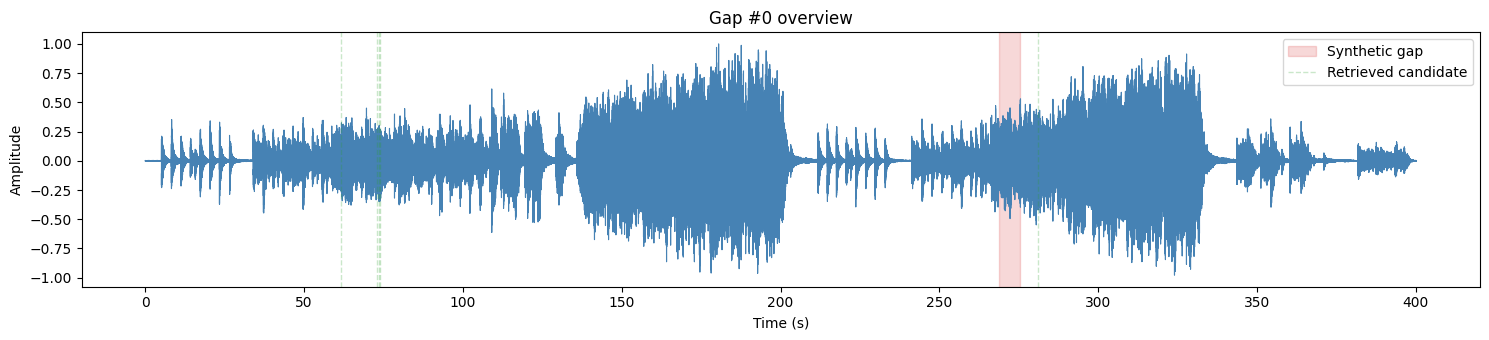

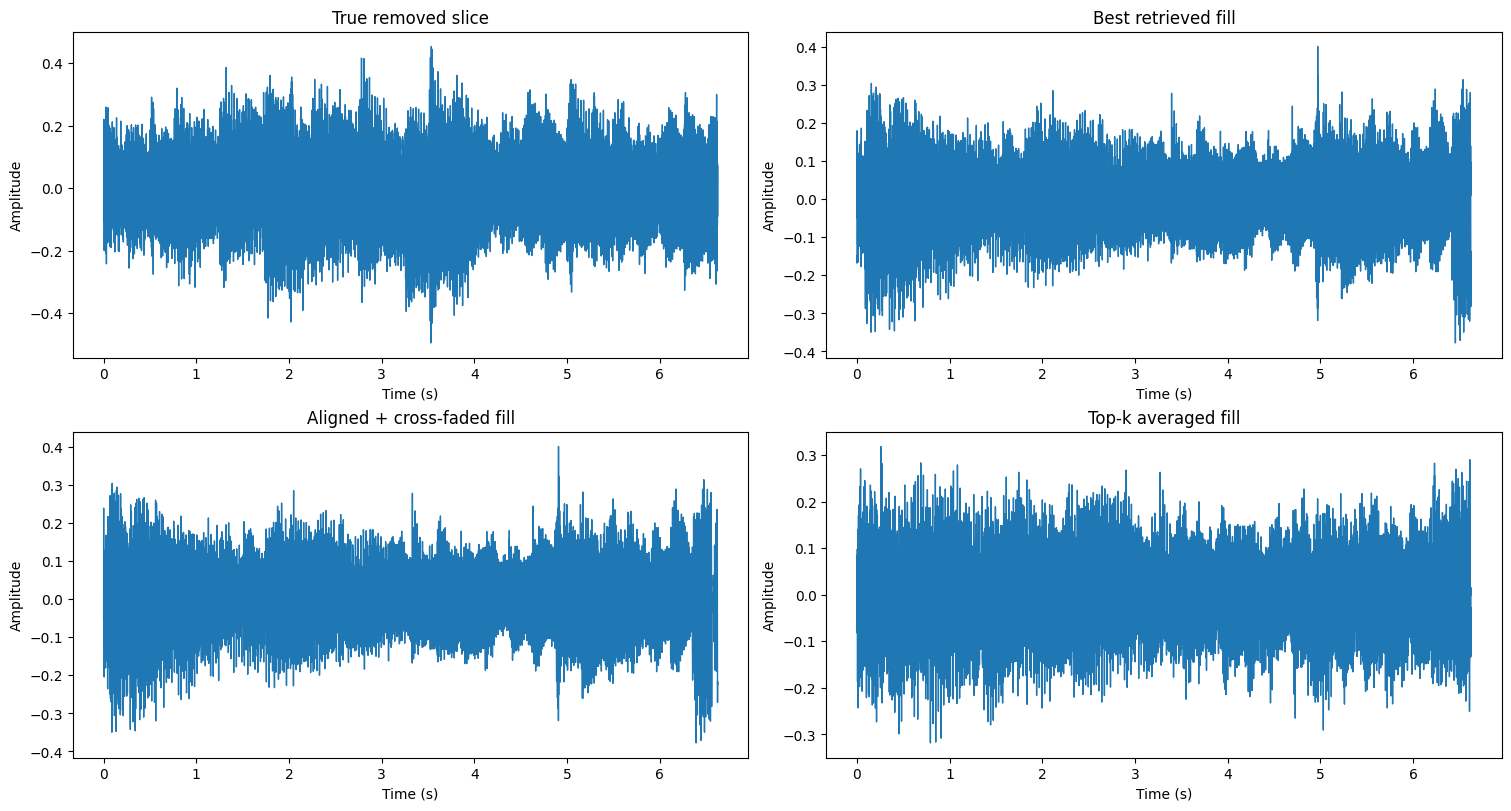

In [ ]:
display(Markdown("## Visualization and listening"))
if not case_outputs:
    display(Markdown("No cases available for visualization."))
else:
    max_cases = min(int(EXPERIMENT["max_visualized_cases"]), len(case_outputs))
    for payload in case_outputs[:max_cases]:
        case = payload["case"]
        display(Markdown(f"### Gap #{case.gap_id} | start={case.gap_start / sr:.2f}s | duration={case.gap_duration_s:.2f}s"))
        plot_gap_case(
            audio=audio,
            sr=sr,
            case=case,
            ranked_candidates=payload["ranked"],
            copy_fill=payload["copy_fill"],
            aligned_fill=payload["aligned_fill"],
            topk_fill=payload["topk_fill"],
            topk_avg_mag=payload["topk_avg_mag"],
        )

        display(Markdown("True removed slice"))
        display(Audio(peak_normalize(case.true_gap_audio), rate=sr))
        display(Markdown("Best candidate fill"))
        display(Audio(peak_normalize(payload["copy_fill"]), rate=sr))
        display(Markdown("Aligned + cross-faded fill"))
        display(Audio(peak_normalize(payload["aligned_fill"]), rate=sr))
        display(Markdown("Top-k averaged fill"))
        display(Audio(peak_normalize(payload["topk_fill"]), rate=sr))
        display(Markdown("Reconstructed song with copied fill"))
        display(Audio(peak_normalize(payload["recon_copy"]), rate=sr))
        display(Markdown("Reconstructed song with aligned + cross-faded fill"))
        display(Audio(peak_normalize(payload["recon_align"]), rate=sr))
        display(Markdown("Reconstructed song with top-k averaged fill"))
        display(Audio(peak_normalize(payload["recon_topk"]), rate=sr))

        if bool(EXPERIMENT["export_audio_examples"]):
            case_dir = artifact_root / f"gap_{case.gap_id:02d}"
            export_case_artifacts(
                out_dir=case_dir,
                sr=sr,
                case=case,
                copy_fill=payload["copy_fill"],
                aligned_fill=payload["aligned_fill"],
                topk_fill=payload["topk_fill"],
                recon_copy=payload["recon_copy"],
                recon_align=payload["recon_align"],
                recon_topk=payload["recon_topk"],
            )
            print(f"Exported audio artifacts to: {case_dir}")


## Qualitative Conclusion Template

Use the plots, listening examples, and summary table to answer the research question:

> On this single song, how much can same-song repetition alone help recover missing slices before training a neural retrieval-conditioned model?

Practical interpretation:

- If `copy_best_candidate_fill` already performs well, the song contains reusable repeated material and a retrieval-aware model has a strong ceiling to exploit.
- If `align + cross-fade` improves audibility while feature metrics move only slightly, the main bottleneck is probably boundary consistency rather than retrieval itself.
- If `top-k weighted average` helps in feature metrics but sounds blurry, soft retrieval may be useful as a conditioning signal even if direct waveform reconstruction is weak.
- If the oracle diagnostic finds a very similar reusable region but context retrieval ranks it poorly, the song has repetition but the query representation is too weak.
- If even the oracle diagnostic cannot find a close same-song slice, repetition alone is unlikely to solve this gap and a generative model will need to synthesize novel content.

Final notebook note:

- `copy_best_candidate_fill` means direct nearest-neighbor reuse.
- `align + cross-fade` means nearest-neighbor reuse plus simple boundary repair.
- `top-k weighted average in feature space` means soft retrieval that averages multiple plausible fills instead of committing to one slice.
